In [1]:
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.feature_selection.recursive.classifier_cross_validation import ClassifierCrossValidationRecursiveFeatureSelection as classifier

In [2]:
TARGET = 'target_win'
RANDOM_SEED = 32
RFE_XGB_PARAMS = dict(
    n_estimators=5000,
    n_jobs=-1,
    learning_rate=.15,
    early_stopping_rounds=10,
    max_depth=5,
    eval_metric='auc',
    importance_type='total_gain',
    random_state=RANDOM_SEED
)
np.random.seed(RANDOM_SEED)

# Selection metric: 'brier' (proper scoring rule, default) | 'roc_auc' | 'log_loss'.
# Drives the RFE scoring metric, the 1-SE selection direction, and grid_search scoring.
SELECTION_METRIC = 'brier'

In [3]:
MODEL_FEATURES_BEFORE_RFE = pd.read_csv(
    '../../../../../data/predict_games/model_features_in/xgb_features_list.csv'
)
INPUT_DATA = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

In [4]:
MODEL_FEATURES_BEFORE_RFE

,feature
0,week
1,div_game
2,target_days_since_previous_game
3,target_off_cumulative_score
4,target_off_cumulative_avg_score
...,...
3244,def_target_snap_share_competitive_cumulative_a...
3245,def_target_snap_share_garbage_trailing_cumulat...
3246,def_target_snap_share_garbage_leading_cumulati...
3247,is_home_target


In [5]:
INPUT_DATA

,game_id,season,week,opp_team,opp_score,target_team,target_score,div_game,target_days_since_previous_game,target_off_cumulative_score,...,def_target_goalToGo_success_rate_pass_garbage_trailing_cumulative_average_rank_change,def_target_goalToGo_success_rate_pass_garbage_leading_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_competitive_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_garbage_trailing_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_garbage_leading_cumulative_average_rank_change,def_target_snap_share_competitive_cumulative_average_rank_change,def_target_snap_share_garbage_trailing_cumulative_average_rank_change,def_target_snap_share_garbage_leading_cumulative_average_rank_change,is_home_target,target_win
0,2003_02_WAS_ATL,2003,2,WAS,33.0,ATL,31.0,0,7.0,27.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,2003_02_CLE_BAL,2003,2,CLE,13.0,BAL,33.0,1,7.0,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
2,2003_02_DET_GB,2003,2,DET,6.0,GB,31.0,1,7.0,25.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
3,2003_02_TEN_IND,2003,2,TEN,7.0,IND,33.0,1,7.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
4,2003_02_BUF_JAX,2003,2,BUF,38.0,JAX,17.0,0,7.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,2025_18_ARI_LA,2025,18,LA,37.0,ARI,20.0,1,7.0,335.0,...,0.0,1.0,2.0,0.0,0.0,-2.0,6.0,-1.0,0,0
11894,2025_18_KC_LV,2025,18,LV,14.0,KC,12.0,1,10.0,350.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0,0
11895,2025_18_MIA_NE,2025,18,NE,38.0,MIA,10.0,1,7.0,337.0,...,0.0,0.0,1.0,0.0,0.0,2.0,-1.0,0.0,0,0
11896,2025_18_WAS_PHI,2025,18,PHI,17.0,WAS,24.0,1,10.0,332.0,...,0.0,0.0,1.0,-1.0,0.0,2.0,-1.0,-2.0,0,1


In [6]:
# Rank-only experiment (PR #28): drop every non-rank feature derived from a cumulative
# value -- the cumulative averages, their week-over-week changes, and the cumulative sums --
# keeping only the rank / rank-change features (plus raw per-game stats and context).
# This removes the highly-correlated source columns so RFE can surface the rank signal
# directly. Set RANK_ONLY = False to restore the full-feature pipeline.
RANK_ONLY = True

candidate_features = list(MODEL_FEATURES_BEFORE_RFE['feature'])
if RANK_ONLY:
    candidate_features = [
        f for f in candidate_features
        if 'cumulative' not in f or f.endswith('_rank') or f.endswith('_rank_change')
    ]

# season is no longer a candidate feature (era drift; hold-out lies outside its
# training range) but is still needed for the time-based split below
model_inputs_df = INPUT_DATA[candidate_features + ['season']]
# randomize the data
model_inputs_df = model_inputs_df.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)
model_inputs_df

,week,div_game,target_days_since_previous_game,target_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank_change,opp_days_since_previous_game,opp_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank_change,target_def_cumulative_avg_points_allowed_rank,target_def_cumulative_avg_points_allowed_rank_change,...,def_target_goalToGo_success_rate_pass_garbage_leading_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_competitive_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_garbage_trailing_cumulative_average_rank_change,def_target_goalToGo_success_rate_run_garbage_leading_cumulative_average_rank_change,def_target_snap_share_competitive_cumulative_average_rank_change,def_target_snap_share_garbage_trailing_cumulative_average_rank_change,def_target_snap_share_garbage_leading_cumulative_average_rank_change,is_home_target,target_win,season
0,5,1,7.0,2.0,0.0,7.0,11.0,2.0,20.0,-7.0,...,1.0,-3.0,0.0,0.0,-4.0,0.0,2.0,1,1,2011
1,8,1,8.0,6.0,-7.0,8.0,8.0,3.0,5.0,-5.0,...,0.0,-3.0,0.0,0.0,-5.0,-3.0,3.0,0,0,2022
2,17,1,6.0,23.0,1.0,7.0,16.0,0.0,18.0,-1.0,...,0.0,1.0,0.0,0.0,4.0,-1.0,-4.0,0,0,2017
3,1,0,240.0,27.0,-1.0,240.0,18.0,2.0,16.0,0.0,...,0.0,-6.0,1.0,0.0,1.0,-3.0,0.0,0,0,2024
4,5,1,14.0,11.0,0.0,7.0,24.0,-4.0,10.0,-1.0,...,1.0,0.0,0.0,0.0,2.0,-3.0,-6.0,0,0,2005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11893,15,1,4.0,1.0,0.0,4.0,5.0,-1.0,28.0,1.0,...,2.0,1.0,0.0,0.0,2.0,0.0,0.0,1,0,2018
11894,4,1,7.0,1.0,-2.0,7.0,2.0,-6.0,21.0,2.0,...,0.0,1.0,0.0,0.0,-18.0,0.0,10.0,0,0,2023
11895,1,0,240.0,8.0,0.0,240.0,32.0,0.0,22.0,-2.0,...,1.0,1.0,0.0,0.0,2.0,-2.0,-2.0,0,0,2017
11896,1,0,240.0,7.0,1.0,240.0,1.0,-1.0,5.0,3.0,...,-1.0,-1.0,1.0,0.0,1.0,2.0,-1.0,0,0,2018


# Create train, test, holdout
We use train at first here until cross validation is ready within a recursive feature elimination framework

In [7]:
# Feature selection uses all pre-holdout data. The holdout is now 2024+2025, so train is
# every season before 2024. (The 2022-2023 early-stopping slice is only carved out later, at
# final-model fitting time in grid_search; including it in feature selection is fine.)
train_df = model_inputs_df[(model_inputs_df['season'] < 2024)]
holdout_df = model_inputs_df[model_inputs_df['season'] >= 2024]
X_train = train_df.drop(columns=[TARGET, 'season'])
y_train = train_df[TARGET]
X_holdout = holdout_df.drop(columns=[TARGET, 'season'])
y_holdout = holdout_df[TARGET]

# Begin Recursive Feature Elimination


In [8]:
rfe = classifier(
    X_train, y_train, RFE_XGB_PARAMS, model_score_metric=SELECTION_METRIC
)

def _log_progress(row):
    with open('/tmp/xgb_rfe_progress.log', 'a') as f:
        f.write(f"iter {row['iteration']}/{row['max_iter']}: "
                f"{row['num_features']} features, cv {row['score']:.4f}\n")

rfe.get_optimal_features_no_grouped_records(
    max_iter=60, min_features=5, verbose=1, on_iteration=_log_progress
)

Iteration 1 of 60


Iteration 2 of 60


Iteration 3 of 60


Iteration 4 of 60


Iteration 5 of 60


...

Iteration 35 of 60


Iteration 36 of 60


Iteration 37 of 60


Iteration 38 of 60


Iteration 39 of 60


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='brier'>)

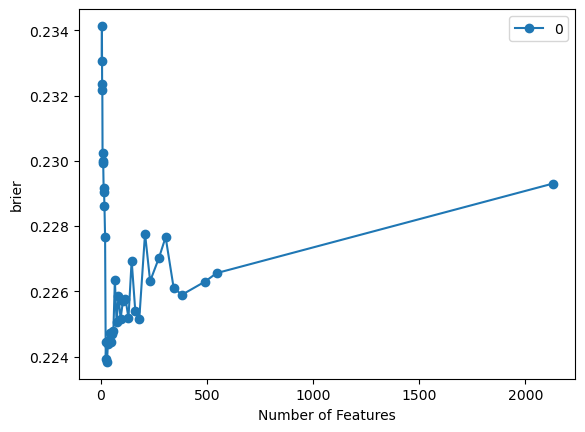

In [9]:
rfe.plot_model_scores()

In [10]:
features_df = rfe.get_features_in_dataframe()
_suffix = '' if SELECTION_METRIC == 'roc_auc' else f'_{SELECTION_METRIC}'
_pool = '' if RANK_ONLY else '_full'
features_df.to_csv(f'../../../../../data/predict_games/model_features_in/rfe_features_kfolds{_pool}{_suffix}.csv')
features_df

,0,1,2,3,4,5,6,7,8,9,...,2118,2119,2120,2121,2122,2123,2124,2125,2126,2127
2128,week,div_game,target_days_since_previous_game,target_off_cumulative_avg_score_rank,target_off_cumulative_avg_score_rank_change,opp_days_since_previous_game,opp_off_cumulative_avg_score_rank,opp_off_cumulative_avg_score_rank_change,target_def_cumulative_avg_points_allowed_rank,target_def_cumulative_avg_points_allowed_rank_...,...,def_target_goalToGo_success_rate_pass_competit...,def_target_goalToGo_success_rate_pass_garbage_...,def_target_goalToGo_success_rate_pass_garbage_...,def_target_goalToGo_success_rate_run_competiti...,def_target_goalToGo_success_rate_run_garbage_t...,def_target_goalToGo_success_rate_run_garbage_l...,def_target_snap_share_competitive_cumulative_a...,def_target_snap_share_garbage_trailing_cumulat...,def_target_snap_share_garbage_leading_cumulati...,is_home_target
546,is_home_target,off_opp_success_rate_competitive_cumulative_av...,off_opp_passing_epa_cumulative_average_rank,opp_def_cumulative_avg_points_allowed_rank,off_target_success_rate_competitive_cumulative...,off_target_snap_share_garbage_leading_cumulati...,opp_off_cumulative_avg_score_rank,off_target_epa_per_play_garbage_leading_cumula...,def_opp_rushing_yards_cumulative_average_rank,off_opp_early_down_success_rate_competitive_cu...,...,None,None,None,None,None,None,None,None,None,None
491,is_home_target,off_opp_success_rate_competitive_cumulative_av...,off_opp_passing_epa_cumulative_average_rank,opp_def_cumulative_avg_points_allowed_rank,off_target_success_rate_competitive_cumulative...,off_target_snap_share_garbage_leading_cumulati...,opp_off_cumulative_avg_score_rank,off_target_epa_per_play_garbage_leading_cumula...,def_opp_rushing_yards_cumulative_average_rank,off_opp_stuff_rate_competitive_cumulative_aver...,...,None,None,None,None,None,None,None,None,None,None
383,is_home_target,def_opp_down2_short_success_rate_run_garbage_t...,off_opp_success_rate_competitive_cumulative_av...,off_opp_stuff_rate_competitive_cumulative_aver...,def_target_run_middle_yards_per_attempt_compet...,opp_off_cumulative_avg_score_rank,off_target_success_rate_competitive_cumulative...,opp_def_cumulative_avg_points_allowed_rank,off_opp_snap_share_garbage_leading_cumulative_...,def_opp_run_right_tackle_explosive_rate_compet...,...,None,None,None,None,None,None,None,None,None,None
344,is_home_target,off_opp_success_rate_competitive_cumulative_av...,off_opp_stuff_rate_competitive_cumulative_aver...,def_target_run_middle_yards_per_attempt_compet...,def_opp_down2_short_success_rate_run_garbage_t...,def_target_run_right_end_explosive_rate_garbag...,off_target_run_left_end_yards_per_attempt_garb...,off_opp_down2_med_success_rate_pass_competitiv...,off_target_interceptions_cumulative_average_rank,off_opp_passing_epa_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
306,is_home_target,off_opp_passing_epa_cumulative_average_rank,off_target_success_rate_competitive_cumulative...,off_opp_snap_share_garbage_leading_cumulative_...,off_target_early_down_success_rate_competitive...,def_opp_down2_short_success_rate_run_garbage_t...,off_opp_early_down_success_rate_competitive_cu...,off_target_snap_share_garbage_leading_cumulati...,def_target_run_middle_yards_per_attempt_compet...,off_target_sack_yards_cumulative_average_rank,...,None,None,None,None,None,None,None,None,None,None
275,is_home_target,off_opp_passing_epa_cumulative_average_rank,off_target_success_rate_competitive_cumulative...,off_opp_snap_share_garbage_leading_cumulative_...,off_target_early_down_success_rate_competitive...,def_opp_down2_short_success_rate_run_garbage_t...,off_target_sack_yards_cumulative_average_rank,def_opp_fumble_lost_rate_competitive_cumulativ...,off_opp_success_rate_competitive_cumulative_av...,def_target_run_middle_yards_per_attempt_compet...,...,None,None,None,None,None,None,None,None,None,None
233,is_home_target,off_opp_success_rate_competitive_cumulative_av...,off_target_snap_share_garbage_lea

In [11]:
best_num_feats = rfe.get_best_num_features_1se()
print(f'1-SE selected feature count ({SELECTION_METRIC}):', best_num_feats)
best_num_feats

1-SE selected feature count (brier): 24


24

In [12]:
rfe._get_metric_values()

,0
2128,0.229300
546,0.226559
491,0.226298
383,0.225897
344,0.226098
306,0.227663
275,0.227034
233,0.226312
209,0.227771
182,0.225163
